## Seasonal Agriculture Performance Analysis

### 1. Introduction

The dataset represents agricultural activities carried out across different seasons, geographical areas and farming conditions. It contains information related to farming practices, environmental conditions, crop production, resource usage and economic performance.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

### 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

### 3. Importance of the Problem Statement

Seasonal variations can influence different aspects of agricultural activities and performance.

Understanding seasonal patterns through data analytics can help stakeholders:

*   Understand variations in agricultural performance
*   Identify important seasonal trends
*   Compare performance across different periods
*   Understand changing environmental conditions
*   Examine differences in resource usage
*   Identify areas requiring further investigation
*   Support evidence-based agricultural planning

For students, this problem provides an opportunity to work on a focused real-world Data Analytics problem rather than performing a generic analysis of the entire dataset.

### 4. Objective

The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships and differences in agricultural performance.

Students should independently:

*   Explore and understand the dataset.
*   Clean and prepare the data for analysis.
*   Examine how agricultural performance varies across seasons.
*   Identify important seasonal patterns and trends.
*   Investigate relationships between seasonal conditions and agricultural outcomes.
*   Compare relevant groups within different seasons.
*   Identify significant differences or unusual patterns.
*   Apply appropriate statistical and visualization techniques.
*   Interpret findings based on evidence from the dataset.
*   Develop meaningful conclusions and data-driven recommendations.

### 5. Expected Outcomes

At the end of the project, students are expected to:

*   Demonstrate an understanding of seasonal agricultural data.
*   Perform appropriate data cleaning and preparation.
*   Identify important seasonal patterns.
*   Compare agricultural performance across seasons.
*   Discover relationships and variations within the dataset.
*   Select suitable analytical and visualization techniques independently.
*   Interpret analytical findings correctly.
*   Identify significant observations from the data.
*   Develop evidence-based insights.
*   Provide appropriate recommendations based on their findings.
*   Document the complete analysis in a Jupyter Notebook

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Display information about the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

None

### 6. Data Preprocessing and Cleaning

Before proceeding with the analysis, it's crucial to preprocess and clean the data. This involves handling missing values, checking for duplicates, and ensuring appropriate data types.

#### 6.1 Handling Missing Values

In [5]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display columns with missing values and their counts
print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


Given the relatively small number of missing values in `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`, we will impute these with their respective median values. The median is chosen over the mean to be more robust to potential outliers in the data.

In [6]:
# Impute missing values with the median for numerical columns
for column in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

# Verify that there are no more missing values in these columns
print("Missing values after imputation:")
print(df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

Missing values after imputation:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


#### 6.2 Handling Duplicate Values

In [7]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows}")

# If duplicates exist, remove them
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"Number of rows after removing duplicates: {len(df)}")

Number of duplicate rows: 0


### 7. Exploratory Data Analysis (EDA)

In this section, we will explore the dataset to understand its main characteristics, identify patterns, relationships, and potential outliers. We'll start with descriptive statistics and then move to visualizations.

#### 7.1 Descriptive Statistics

In [8]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


#### 7.2 Visualizing Seasonal Differences

1.   List item
2.   List item



To understand how agricultural performance changes across seasons, we will visualize key metrics grouped by season.

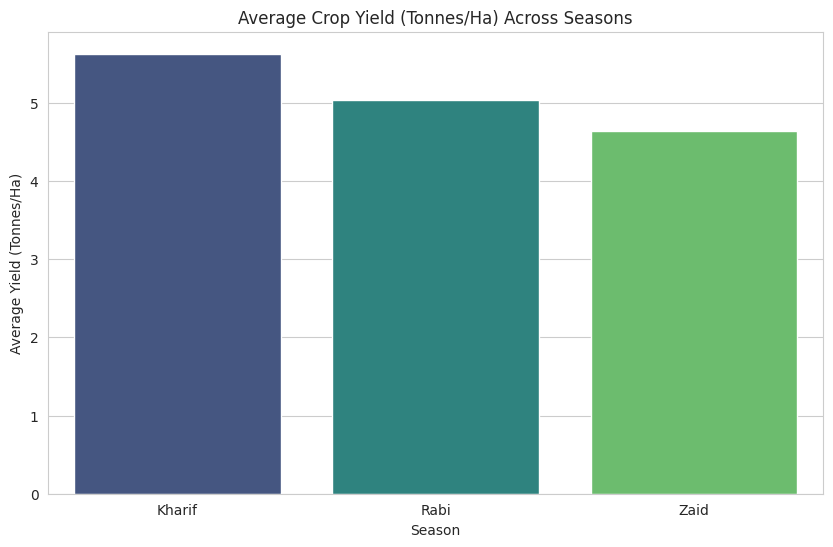

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Group data by 'Season' and calculate the mean of 'Yield_Tonnes_Ha'
seasonal_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index()

# Create a bar plot, addressing the FutureWarning by specifying hue
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=seasonal_yield, palette='viridis', hue='Season', legend=False)
plt.title('Average Crop Yield (Tonnes/Ha) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

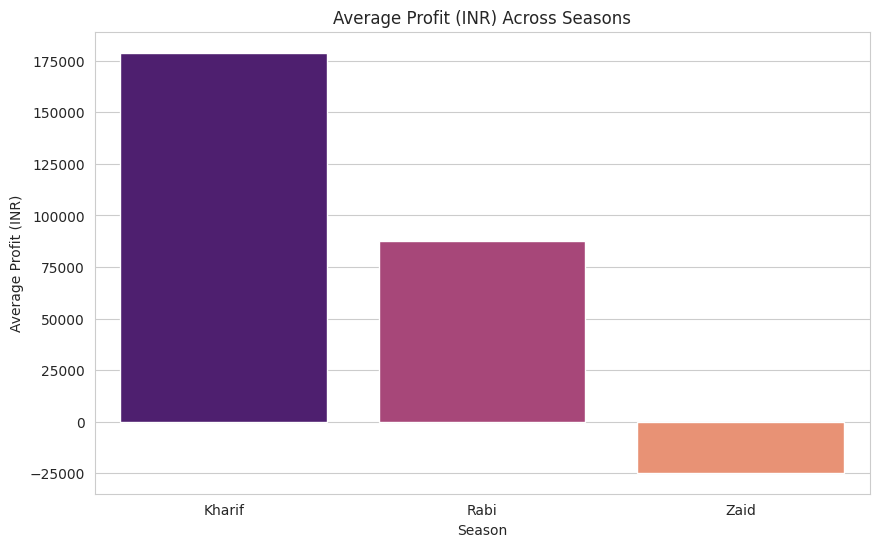

In [10]:
seasonal_profit = df.groupby('Season')['Profit_INR'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Profit_INR', data=seasonal_profit, palette='magma', hue='Season', legend=False)
plt.title('Average Profit (INR) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

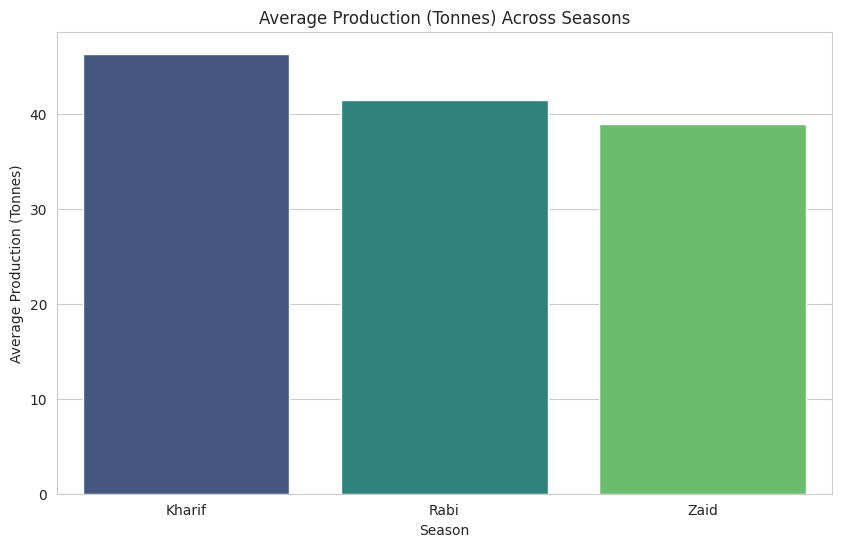

In [11]:
seasonal_production = df.groupby('Season')['Production_Tonnes'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Production_Tonnes', data=seasonal_production, palette='viridis', hue='Season', legend=False)
plt.title('Average Production (Tonnes) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.show()

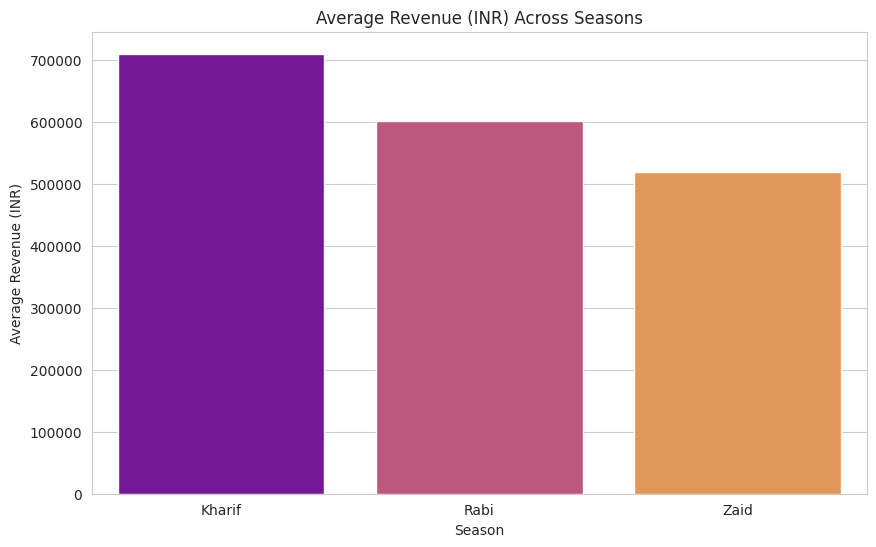

In [12]:
seasonal_revenue = df.groupby('Season')['Revenue_INR'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Revenue_INR', data=seasonal_revenue, palette='plasma', hue='Season', legend=False)
plt.title('Average Revenue (INR) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')
plt.show()

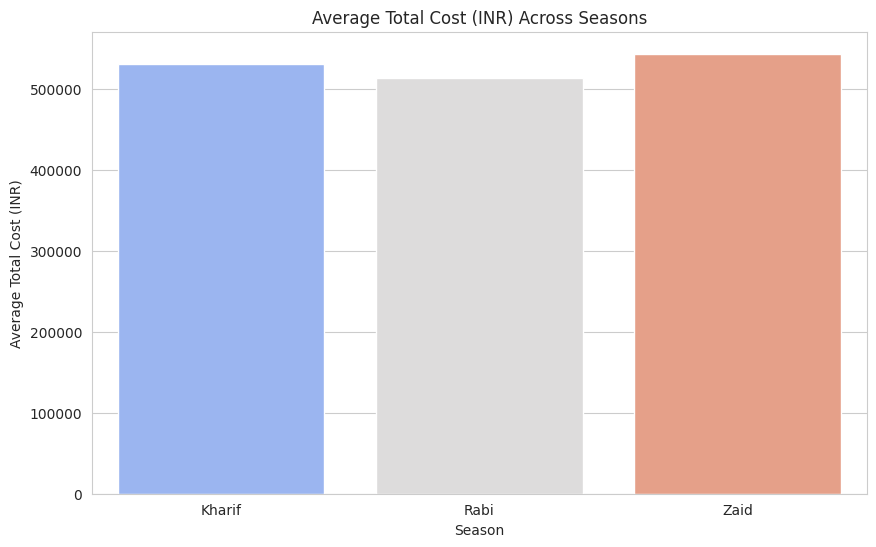

In [13]:
seasonal_total_cost = df.groupby('Season')['Total_Cost_INR'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Total_Cost_INR', data=seasonal_total_cost, palette='coolwarm', hue='Season', legend=False)
plt.title('Average Total Cost (INR) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Total Cost (INR)')
plt.show()

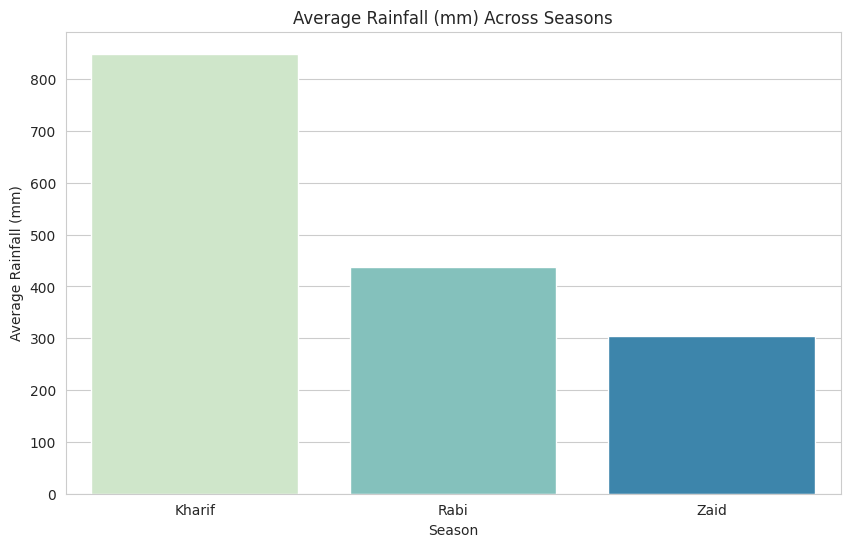

In [14]:
seasonal_rainfall = df.groupby('Season')['Rainfall_mm'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Rainfall_mm', data=seasonal_rainfall, palette='GnBu', hue='Season', legend=False)
plt.title('Average Rainfall (mm) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')
plt.show()

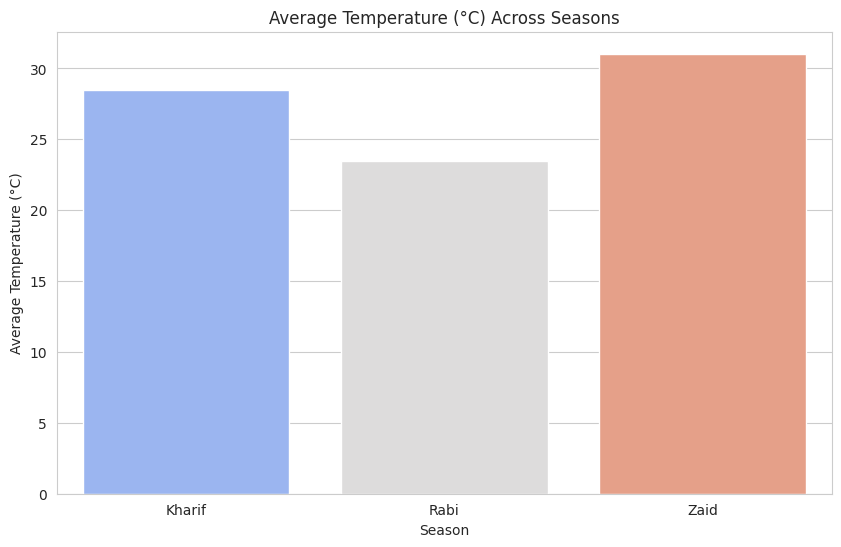

In [15]:
seasonal_temperature = df.groupby('Season')['Avg_Temperature_C'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Avg_Temperature_C', data=seasonal_temperature, palette='coolwarm', hue='Season', legend=False)
plt.title('Average Temperature (°C) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')
plt.show()

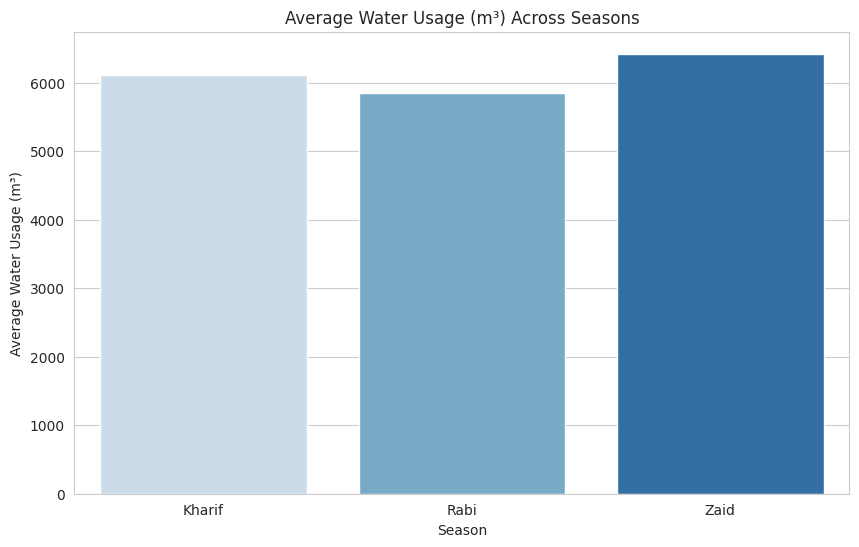

In [16]:
seasonal_water_usage = df.groupby('Season')['Water_Used_m3'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Water_Used_m3', data=seasonal_water_usage, palette='Blues', hue='Season', legend=False)
plt.title('Average Water Usage (m³) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Water Usage (m³)')
plt.show()

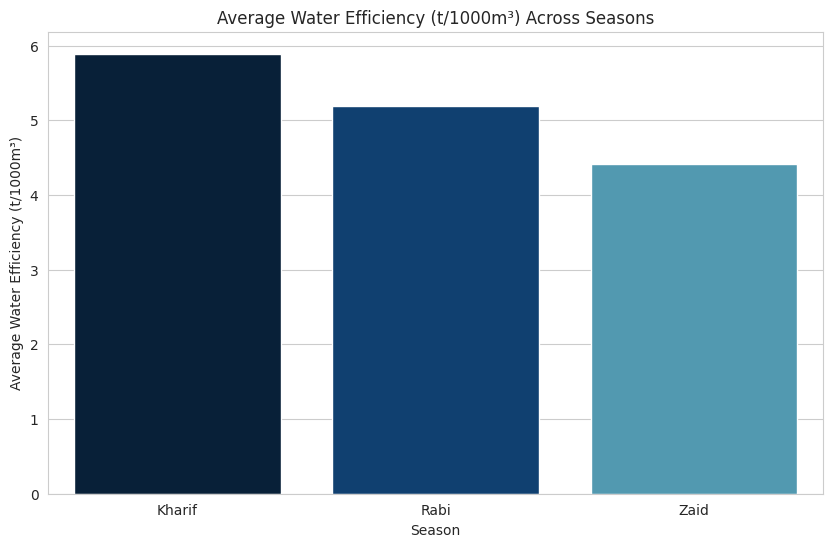

In [17]:
seasonal_water_efficiency = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Water_Efficiency_t_per_1000m3', data=seasonal_water_efficiency, palette='ocean', hue='Season', legend=False)
plt.title('Average Water Efficiency (t/1000m³) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Water Efficiency (t/1000m³)')
plt.show()

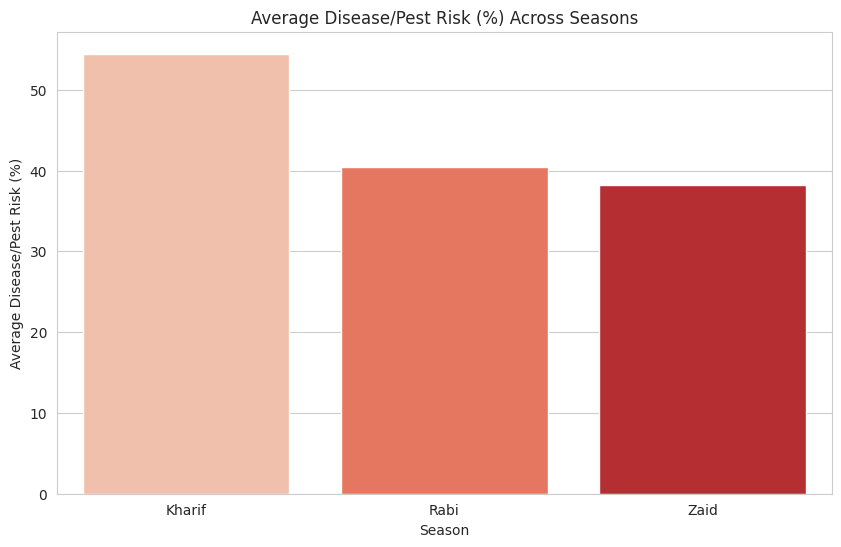

In [18]:
seasonal_disease_risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Disease_Pest_Risk_pct', data=seasonal_disease_risk, palette='Reds', hue='Season', legend=False)
plt.title('Average Disease/Pest Risk (%) Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Disease/Pest Risk (%)')
plt.show()

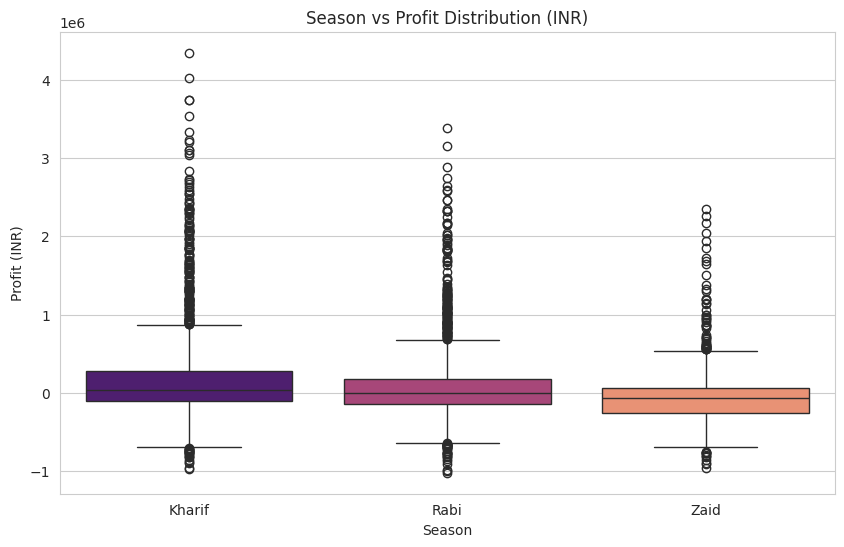

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Profit_INR', data=df, palette='magma', hue='Season', legend=False)
plt.title('Season vs Profit Distribution (INR)')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.show()

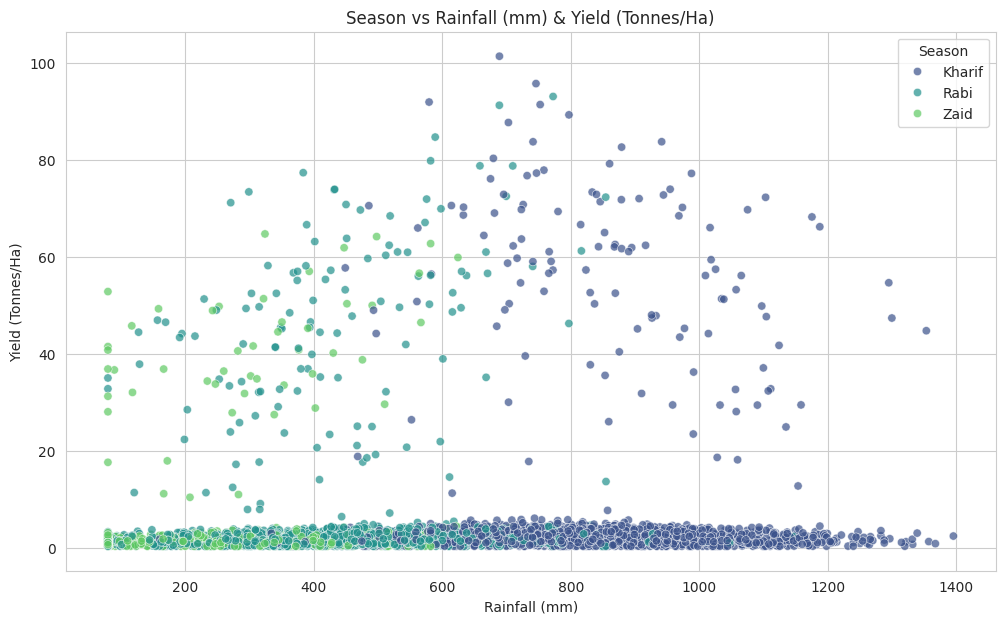

In [20]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', data=df, palette='viridis', alpha=0.7)
plt.title('Season vs Rainfall (mm) & Yield (Tonnes/Ha)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season')
plt.show()

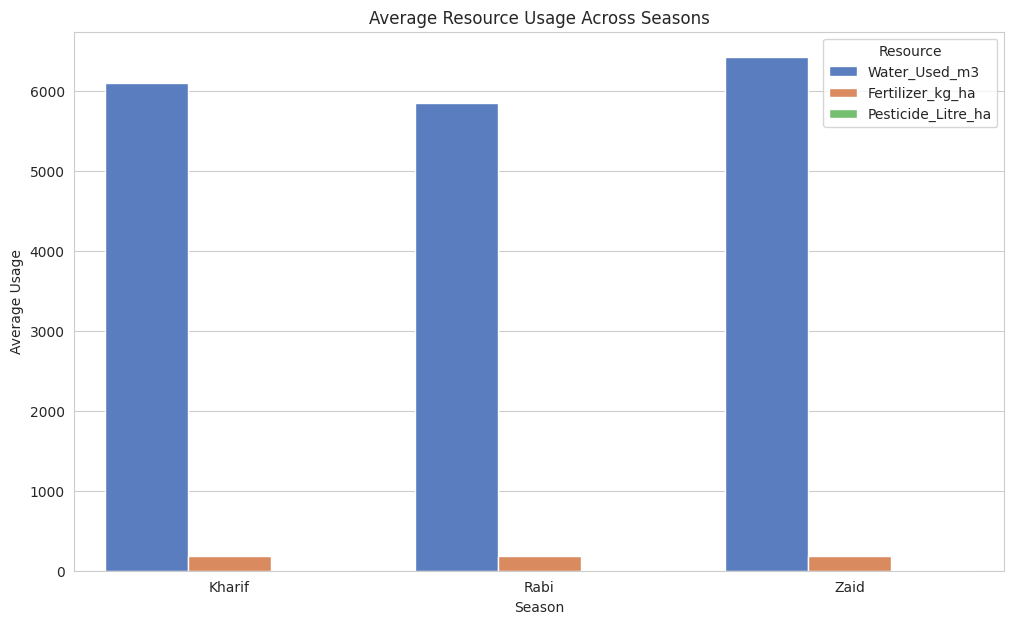

In [21]:
resource_usage = df.groupby('Season')[['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']].mean().reset_index()

resource_usage_melted = resource_usage.melt('Season', var_name='Resource', value_name='Average_Usage')

plt.figure(figsize=(12, 7))
sns.barplot(x='Season', y='Average_Usage', hue='Resource', data=resource_usage_melted, palette='muted')
plt.title('Average Resource Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Usage')
plt.legend(title='Resource')
plt.show()

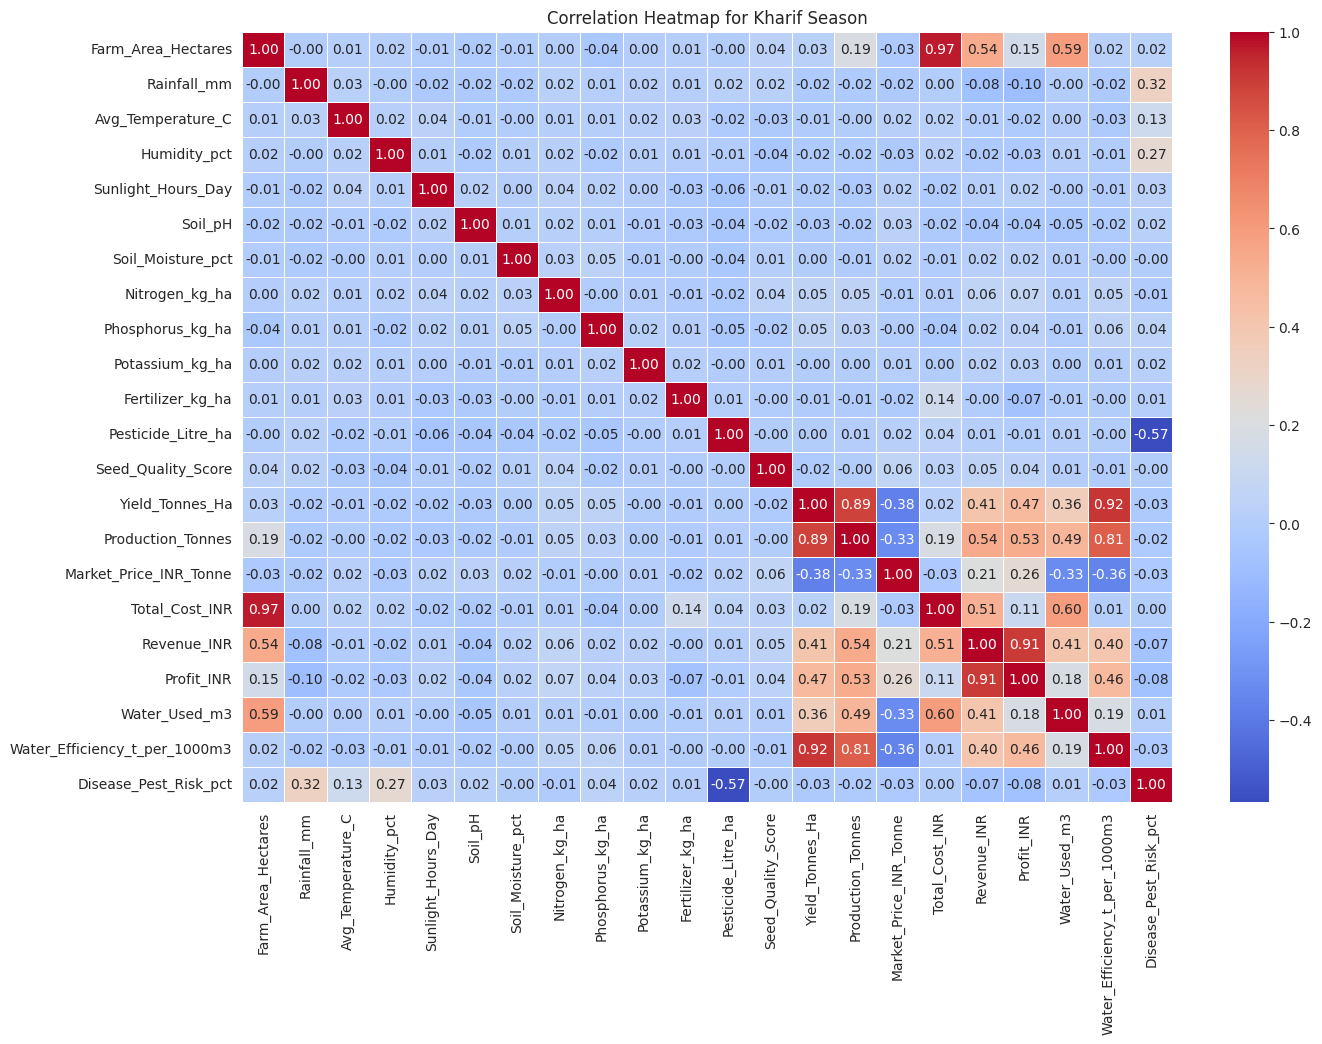

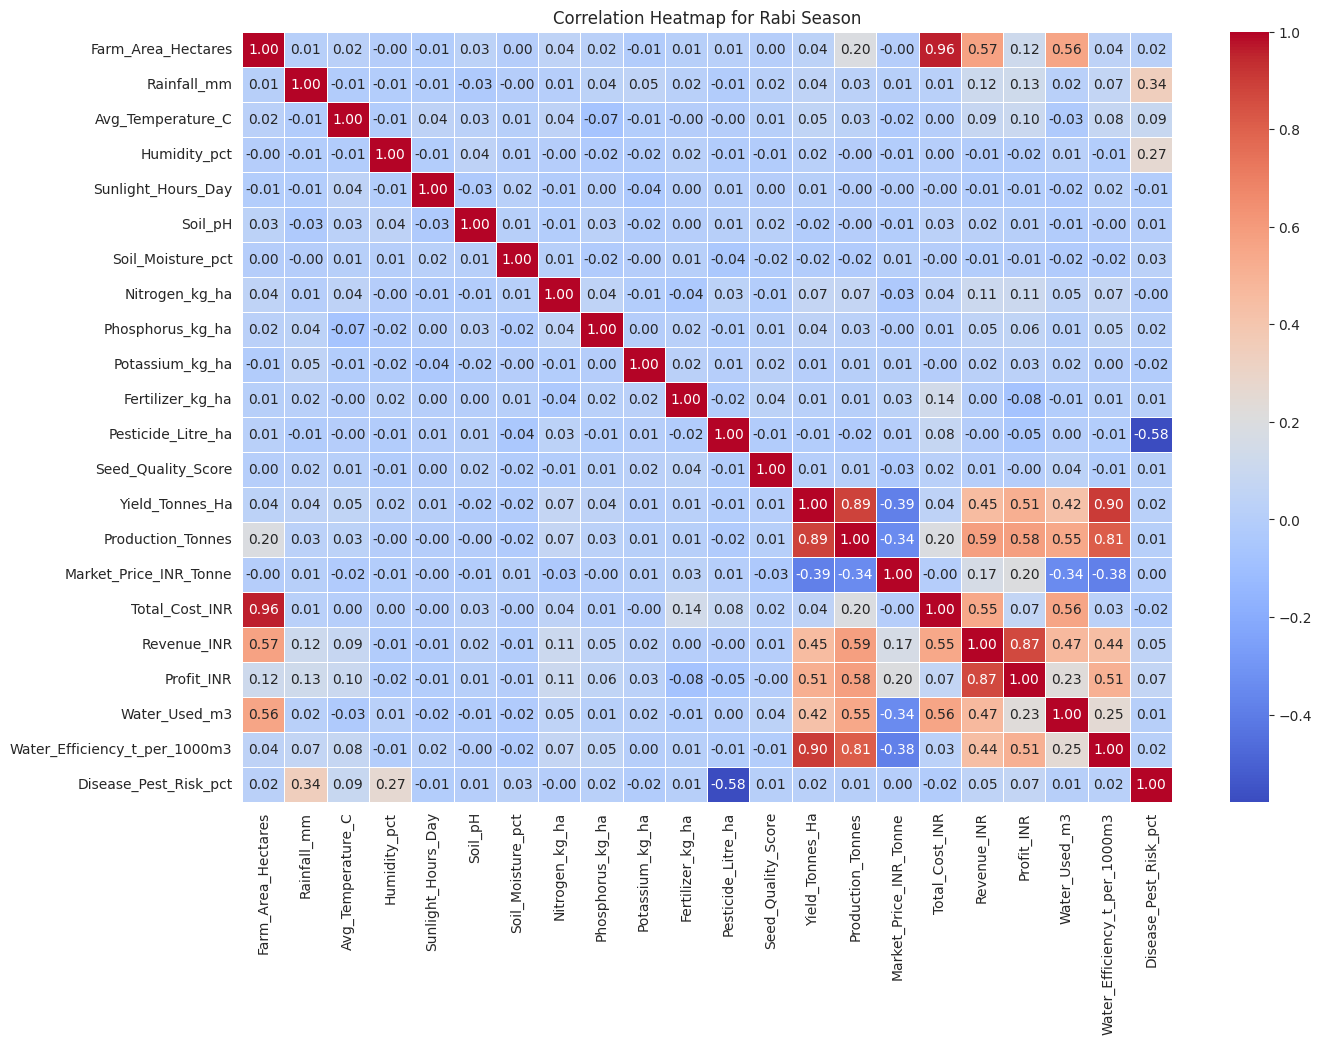

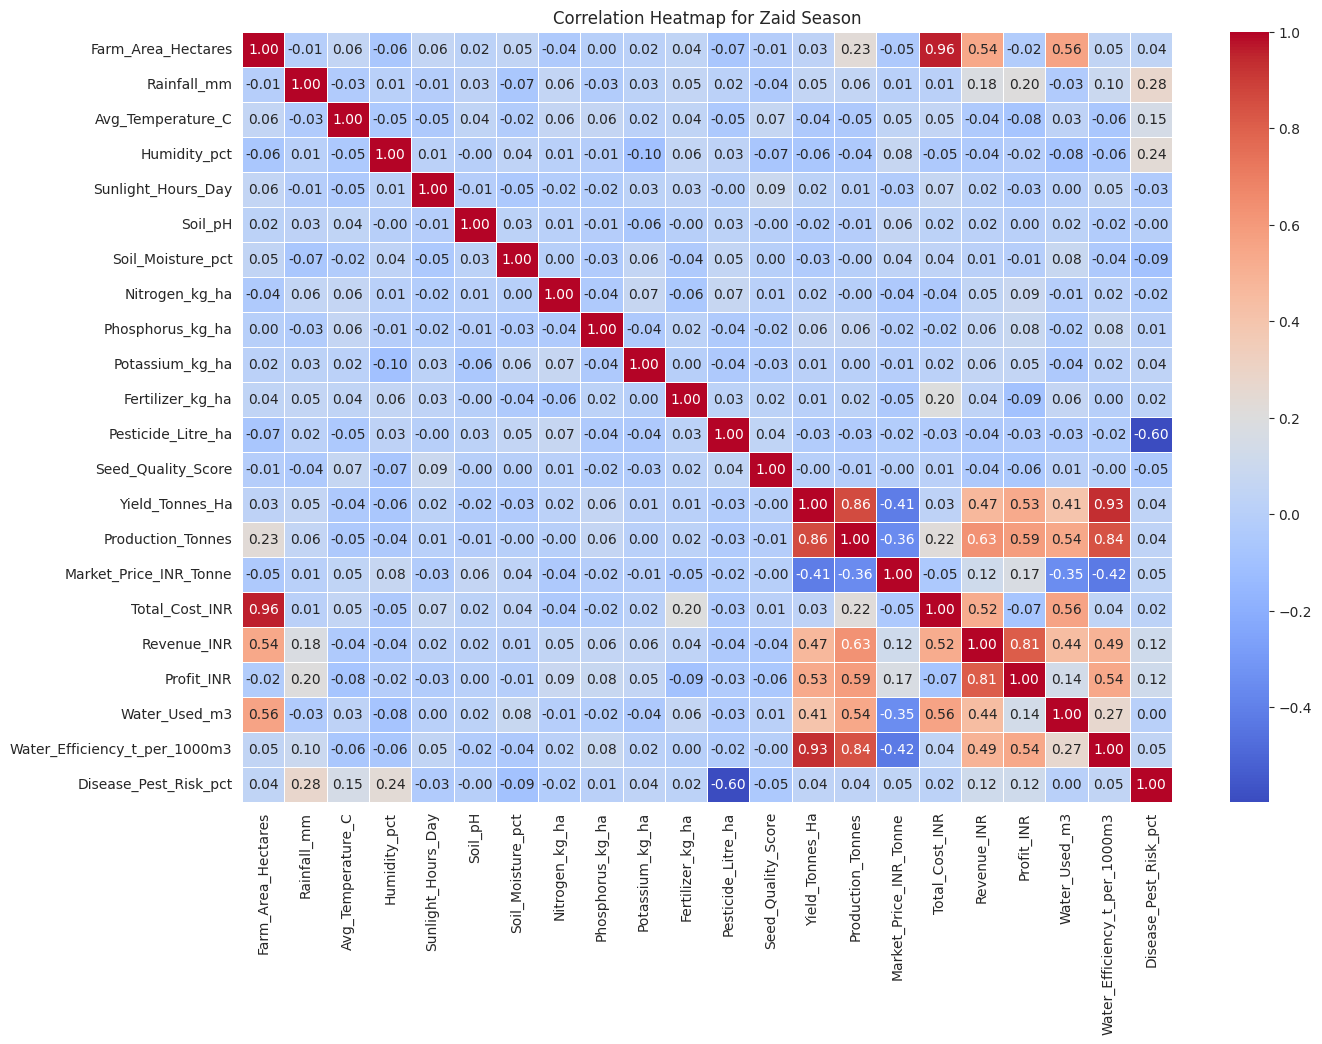

In [22]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.groupby('Season').corr(numeric_only=True).loc['Kharif'], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Kharif Season')
plt.show()

plt.figure(figsize=(15, 10))
sns.heatmap(df.groupby('Season').corr(numeric_only=True).loc['Rabi'], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Rabi Season')
plt.show()

plt.figure(figsize=(15, 10))
sns.heatmap(df.groupby('Season').corr(numeric_only=True).loc['Zaid'], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Zaid Season')
plt.show()